In [2]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

**TAREA**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

Respuesta realizada por Álvaro García Suárez y Marcos González Gómez.

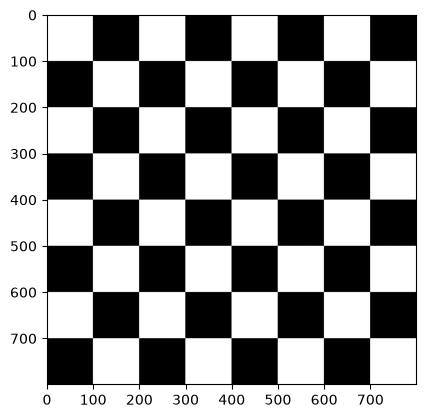

In [3]:
# Dimensiones
width = 800
height = 800

# Creamos una matriz llena de ceros (un fondo completamente negro)
board = np.zeros((height, width, 1), dtype=np.uint8)

# Recorremos la cuadrícula de 8x8 del ajedrez
for fila in range(0, 8):
    for columna in range(0, 8):

        # Pintamos de blanco (255) si la fila y la columna son pares
        if columna % 2 == 0:
            if fila % 2 == 0:
                # Calculamos el bloque de 100x100 píxeles que ocupa la casilla
                board[fila*100:fila*100+100, columna*100:columna*100+100, 0] = 255

        # O pintamos de blanco si la fila y la columna son impares
        else:
            if fila % 2 != 0:
                board[fila*100:fila*100+100, columna*100:columna*100+100, 0] = 255

# Visualiza con matplotlib
plt.imshow(board, cmap='gray', vmin=0, vmax=255)
plt.show()

Respuesta generada por ChatGPT.

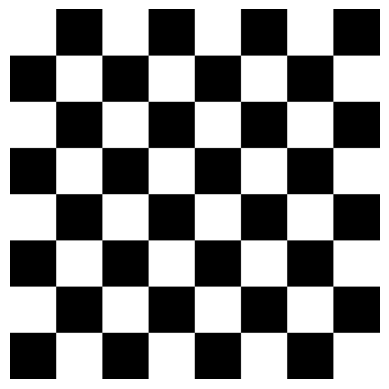

In [4]:
#Dimensiones de la imagen
width = 800
height = 800

#Crear imagen en color (fondo negro inicialmente)
tablero = np.zeros((height, width, 3), dtype=np.uint8)

#Número de casillas por lado
n = 8

#Tamaño de cada casilla
tam_casilla = width // n

#Colores en RGB
color1 = (255, 255, 255)   # blanco
color2 = (0, 0, 0)         # negro

#Dibujar las casillas
for fila in range(n):
    for columna in range(n):
        x1 = columna * tam_casilla
        y1 = fila * tam_casilla
        x2 = x1 + tam_casilla
        y2 = y1 + tam_casilla

        if (fila + columna) % 2 == 0:
            color = color1
        else:
            color = color2

        cv2.rectangle(tablero, (x1, y1), (x2, y2), color, -1)

#Mostrar imagen
plt.imshow(tablero)
plt.axis('off')
plt.show()

Comparando ambas versiones, considero que nuestra solución es más sencilla y directa, ya que consigue generar el tablero utilizando menos elementos y sin complicar demasiado el código. Sin embargo, la versión generada con IA resulta visualmente más clara y está mejor estructurada, haciendo que sea más fácil entender cómo se construye cada casilla.

**TAREA**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

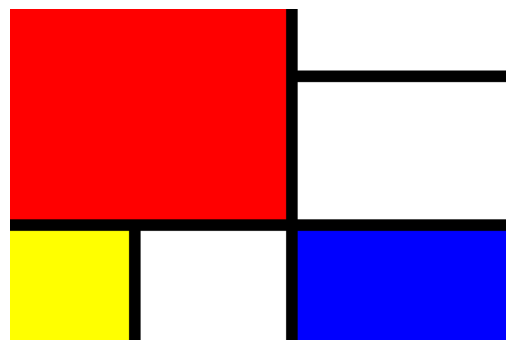

True

In [5]:
# Imagen inicial con tres planos
ancho = 300
alto = 200
color_img = np.zeros((alto, ancho, 3), dtype=np.uint8)

# Rellena el fondo de blanco
color_img[:] = 255

# Bloques de colores primarios
cv2.rectangle(color_img, (0, 0), (int(ancho/2) + 20, int(alto/2) + 30), (255, 0, 0), -1)      # Rojo
cv2.rectangle(color_img, (int(ancho/2) + 20, int(alto/2) + 30), (ancho, alto), (0, 0, 255), -1) # Azul
cv2.rectangle(color_img, (0, int(alto/2) + 30), (int(ancho/4), alto), (255, 255, 0), -1)      # Amarillo

# Cuadrícula de líneas negras (grosor 6)
cv2.line(color_img, (int(ancho/2) + 20, 0), (int(ancho/2) + 20, alto), (0, 0, 0), 6)
cv2.line(color_img, (0, int(alto/2) + 30), (ancho, int(alto/2) + 30), (0, 0, 0), 6)
cv2.line(color_img, (int(ancho/4), int(alto/2) + 30), (int(ancho/4), alto), (0, 0, 0), 6)
cv2.line(color_img, (int(ancho/2) + 20, 40), (ancho, 40), (0, 0, 0), 6)

# Visualiza
plt.imshow(color_img) 
plt.axis('off')
plt.show()

# Guarda a disco (convirtiendo de RGB a BGR para OpenCV)
color_img_bgr = cv2.cvtColor(color_img, cv2.COLOR_RGB2BGR)
cv2.imwrite('mondrian.jpg', color_img_bgr)

**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.

In [9]:
import cv2

vid = cv2.VideoCapture(0)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()
  
    # Hay nuevo fotograma
    if ret:

        # Reducimos la resolución a la mitad para mayor velocidad 
        #frame = cv2.resize(frame, (0, 0), fx=0.75, fy=0.75)

        # Convertimos a escala de grises
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # Encontramos los píxeles más oscuros y más claros
        _, _, min_loc, max_loc = cv2.minMaxLoc(gray)
        
        # --- PÍXEL MÁS OSCURO ---
        cv2.circle(frame, min_loc, 10, (255, 0, 0), 2)
        # Añadimos texto azul desplazado un poco (x+20, y-20)
        cv2.putText(frame, 'Oscuro', (min_loc[0] + 20, min_loc[1] - 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
        
        # --- PÍXEL MÁS CLARO ---
        cv2.circle(frame, max_loc, 10, (0, 0, 255), 2)
        # Añadimos texto rojo desplazado un poco (x+20, y-20)
        cv2.putText(frame, 'Claro', (max_loc[0] + 20, max_loc[1] - 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

        # Muestra fotograma
        cv2.imshow('Vid', frame)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

En cuanto a la pregunta, consideramos que funciona de forma fluida, por lo que no había necesidad de acelerarlo. En caso de que fuese necesario, se podría reducir la ventana a la mitad, lo que reduciría el número de píxeles a una cuarta parte, haciendo el procesamiento más rápido.


TAREA: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

In [8]:
vid = cv2.VideoCapture(0)

# Dimensiones de la cámara
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH) / 3)
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT) / 3)


# Función que aplica una paleta de 5 colores según la luminosidad
def aplicar_paleta(gris, c1, c2, c3, c4, c5):

    # Creamos una imagen vacía
    imagen = np.zeros((gris.shape[0], gris.shape[1], 3), dtype=np.uint8)

    # Asignamos un color dependiendo de la luminosidad
    imagen[gris < 50] = c1
    imagen[(gris >= 50) & (gris < 100)] = c2
    imagen[(gris >= 100) & (gris < 150)] = c3
    imagen[(gris >= 150) & (gris < 200)] = c4
    imagen[gris >= 200] = c5

    return imagen


while(True):

    # Fotograma a fotograma
    ret, frameIN = vid.read()

    # Hay nuevo fotograma
    if ret:

        # Reducimos el tamaño de la imagen
        frame = cv2.resize(
            frameIN,
            (w, h),
            interpolation=cv2.INTER_AREA
        )

        # Convertimos a escala de grises
        gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Suavizamos ligeramente para reducir ruido
        gris_suave = cv2.GaussianBlur(gris, (3, 3), 0)


        # --- PRIMERA GAMA ---
        c1 = aplicar_paleta(
            gris_suave,
            (20, 0, 70),
            (30, 20, 150),
            (40, 80, 230),
            (40, 170, 255),
            (150, 240, 255)
        )


        # --- SEGUNDA GAMA ---
        c2 = aplicar_paleta(
            gris_suave,
            (90, 20, 0),
            (160, 30, 50),
            (200, 20, 160),
            (220, 90, 255),
            (240, 190, 255)
        )


        # --- TERCERA GAMA ---
        c3 = aplicar_paleta(
            gris_suave,
            (20, 60, 0),
            (40, 120, 0),
            (50, 200, 30),
            (50, 240, 160),
            (100, 255, 255)
        )


        # --- CUARTA GAMA ---
        c4 = aplicar_paleta(
            gris_suave,
            (70, 50, 0),
            (130, 100, 0),
            (200, 170, 20),
            (255, 220, 80),
            (255, 255, 180)
        )


        # --- QUINTA GAMA ---
        c5 = aplicar_paleta(
            gris_suave,
            (60, 0, 80),
            (120, 0, 150),
            (180, 20, 220),
            (80, 100, 255),
            (100, 210, 255)
        )


        # --- SEXTA GAMA ---
        c6 = aplicar_paleta(
            gris_suave,
            (120, 20, 0),
            (220, 60, 20),
            (240, 80, 120),
            (220, 140, 230),
            (200, 230, 255)
        )


        # --- SÉPTIMA GAMA ---
        c7 = aplicar_paleta(
            gris_suave,
            (20, 50, 20),
            (20, 100, 80),
            (0, 150, 220),
            (40, 100, 255),
            (180, 180, 255)
        )


        # --- OCTAVA GAMA ---
        c8 = aplicar_paleta(
            gris_suave,
            (80, 10, 10),
            (120, 20, 80),
            (60, 40, 200),
            (20, 130, 255),
            (140, 240, 255)
        )


        # --- NOVENA GAMA ---
        c9 = aplicar_paleta(
            gris_suave,
            (70, 50, 40),
            (130, 70, 100),
            (180, 30, 200),
            (150, 200, 100),
            (210, 255, 210)
        )


        # Aplicamos un umbral adaptativo para remarcar los detalles
        mascara = cv2.adaptiveThreshold(
            gris_suave,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV,
            11,
            3
        )

        # Guardamos las nueve imágenes en una lista
        imagenes = [c1, c2, c3, c4, c5, c6, c7, c8, c9]

        # Pintamos en negro las zonas detectadas por el umbral
        for img in imagenes:
            img[mascara > 0] = (0, 0, 0)


        # Unimos las imágenes por filas
        fila1 = np.hstack((c1, c2, c3))
        fila2 = np.hstack((c4, c5, c6))
        fila3 = np.hstack((c7, c8, c9))

        # Unimos las tres filas
        collage = np.vstack((fila1, fila2, fila3))


        # Grosor de las líneas que separan las viñetas
        grosor = 6

        # Líneas verticales
        cv2.line(collage, (w, 0), (w, h*3), (0, 0, 0), grosor)
        cv2.line(collage, (w*2, 0), (w*2, h*3), (0, 0, 0), grosor)

        # Líneas horizontales
        cv2.line(collage, (0, h), (w*3, h), (0, 0, 0), grosor)
        cv2.line(collage, (0, h*2), (w*3, h*2), (0, 0, 0), grosor)

        # Dibujamos un marco exterior
        cv2.rectangle(
            collage,
            (0, 0),
            (w*3 - 1, h*3 - 1),
            (0, 0, 0),
            grosor
        )

        # Muestra composición
        cv2.imshow("Pop Art", collage)

    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break


# Libera el objeto de captura
vid.release()

# Destruye ventanas
cv2.destroyAllWindows()


LINK CONVERSACIÓN: https://chatgpt.com/share/6aaae81f-a3fc-83eb-8151-f8b58e1c2e2a